In [1]:
import numpy as np

# 1. 创建形状为3×4的随机矩阵X，元素服从标准正态分布
np.random.seed(42)  # 设置随机种子以便结果可重现
X = np.random.randn(3, 4)
print("1. 随机矩阵X:")
print(X)
print()

# 2. 创建形状为4×2的全1矩阵Y
Y = np.ones((4, 2))
print("2. 全1矩阵Y:")
print(Y)
print()

# 3. 计算矩阵乘法Z = X × Y
Z = np.dot(X, Y)  # 或者使用 Z = X @ Y
print("3. 矩阵乘积Z = X × Y:")
print(Z)
print()

# 4. 输出Z的第一行和第二列交叉处的元素，以及Z的第2行所有元素
# 注意：索引从0开始
element_0_1 = Z[0, 1]  # 第一行(索引0)和第二列(索引1)交叉处的元素
row_1 = Z[1, :]  # 第2行(索引1)所有元素
print(f"4. Z[0,1] = {element_0_1}")
print(f"   Z的第2行(索引1)所有元素: {row_1}")
print()

# 5. 计算Z的Frobenius范数
frobenius_norm = np.linalg.norm(Z, 'fro')
print(f"5. Z的Frobenius范数: {frobenius_norm}")

1. 随机矩阵X:
[[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]]

2. 全1矩阵Y:
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

3. 矩阵乘积Z = X × Y:
[[ 2.52916825  2.52916825]
 [ 1.87835721  1.87835721]
 [-0.85606179 -0.85606179]]

4. Z[0,1] = 2.5291682463487657
   Z的第2行(索引1)所有元素: [1.87835721 1.87835721]

5. Z的Frobenius范数: 4.616873319476864


--- 中心极限定理模拟 ---
参数设置:
• 每次抽取 n = 10000 个均匀分布 U(0,1) 随机变量
• 重复实验 m = 1000 次
• 总共生成 10,000,000 个随机数

1. 生成随机变量并计算均值...
  完成！已计算 1000 个样本均值
  第一个样本均值: 0.494242
  最后一个样本均值: 0.502628

2. 统计结果:
  • 样本均值的均值: 0.499993
  • 总体均值(理论值): 0.500000
  • 差值: 0.000007

  • 样本均值的实际方差: 0.00000831
  • 样本均值的理论方差(总体方差/n): 0.00000833
  • 相对误差: 0.23%

  • 样本均值的实际标准差: 0.002883
  • 样本均值的理论标准差: 0.002887

3. 绘制直方图和理论正态分布曲线...


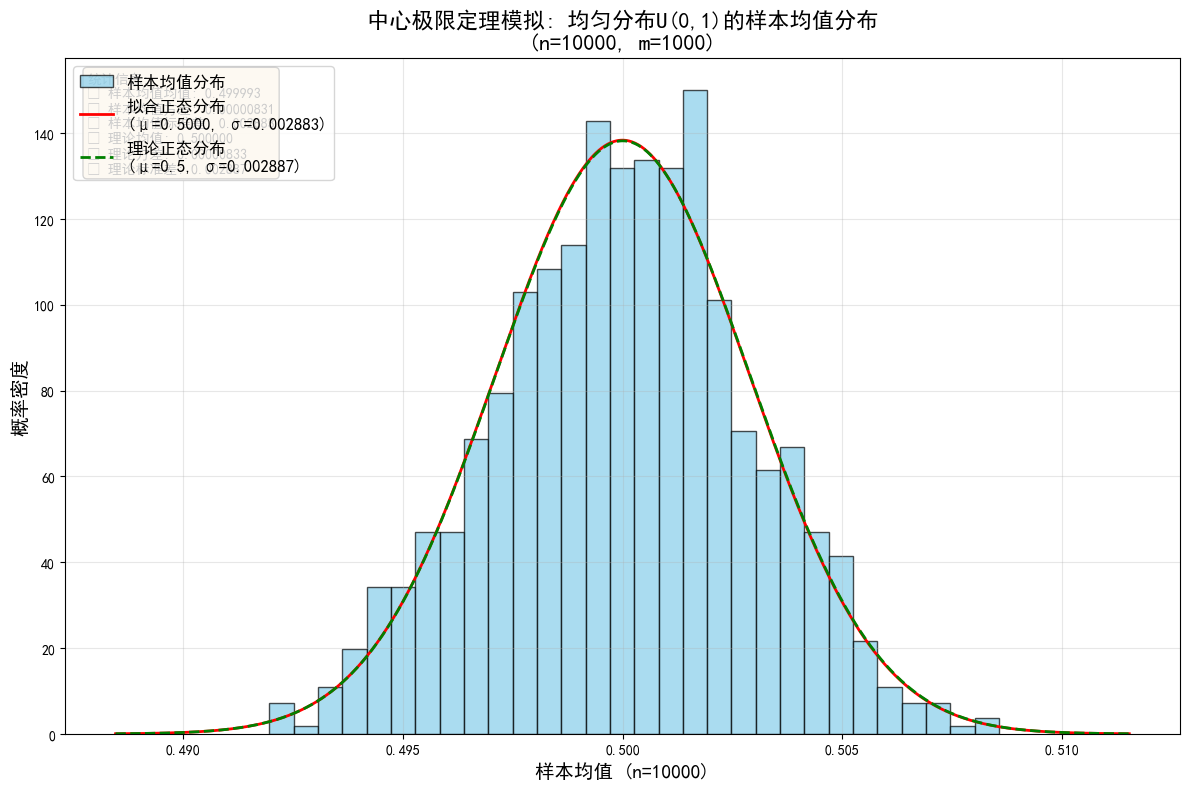


4. 绘制QQ图检查正态性...


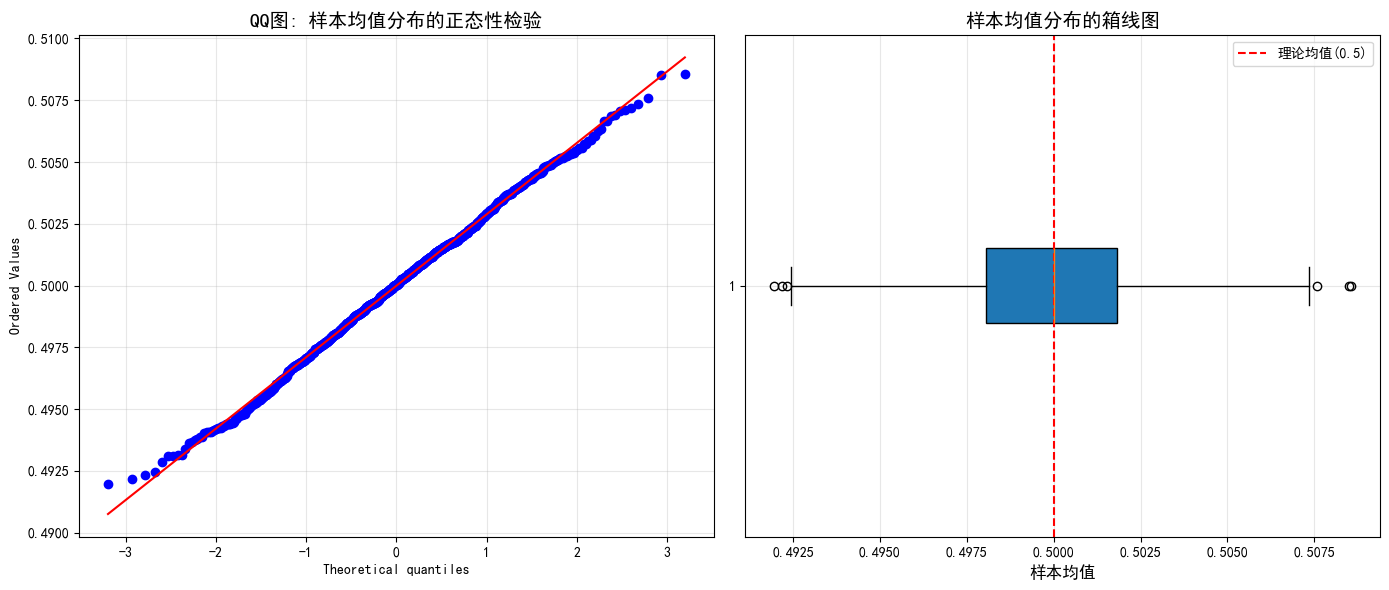


--- 中心极限定理验证总结 ---
1. 样本均值的分布近似正态分布，尽管原始数据来自均匀分布
2. 实际均值(0.499993)接近理论均值(0.5)
3. 实际方差(0.00000831)接近理论方差(0.00000833)
4. 相对误差: 0.23%
5. 随着样本量n增大，样本均值的方差减小(方差 = 1/(12n))


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

def simulate_central_limit_theorem():
    # 参数设置
    n = 10000  # 每次抽取的样本数量
    m = 1000   # 重复实验次数
    
    print("--- 中心极限定理模拟 ---")
    print(f"参数设置:")
    print(f"• 每次抽取 n = {n} 个均匀分布 U(0,1) 随机变量")
    print(f"• 重复实验 m = {m} 次")
    print(f"• 总共生成 {n * m:,} 个随机数\n")
    
    # 1. 生成随机变量并计算均值
    print("1. 生成随机变量并计算均值...")
    sample_means = np.zeros(m)
    
    for i in range(m):
        # 生成n个服从均匀分布U(0,1)的随机变量
        samples = np.random.uniform(0, 1, n)
        # 计算这n个变量的均值
        sample_means[i] = np.mean(samples)
    
    print(f"  完成！已计算 {m} 个样本均值")
    print(f"  第一个样本均值: {sample_means[0]:.6f}")
    print(f"  最后一个样本均值: {sample_means[-1]:.6f}")
    
    # 2. 计算均值的统计量
    mean_of_means = np.mean(sample_means)
    actual_variance = np.var(sample_means)
    std_of_means = np.std(sample_means)
    
    # 理论值（根据中心极限定理）
    # 均匀分布U(0,1)的均值为0.5，方差为1/12
    population_mean = 0.5
    population_variance = 1/12
    
    # 样本均值的理论方差 = 总体方差 / n
    theoretical_variance = population_variance / n
    theoretical_std = np.sqrt(theoretical_variance)
    
    print(f"\n2. 统计结果:")
    print(f"  • 样本均值的均值: {mean_of_means:.6f}")
    print(f"  • 总体均值(理论值): {population_mean:.6f}")
    print(f"  • 差值: {abs(mean_of_means - population_mean):.6f}")
    
    print(f"\n  • 样本均值的实际方差: {actual_variance:.8f}")
    print(f"  • 样本均值的理论方差(总体方差/n): {theoretical_variance:.8f}")
    print(f"  • 相对误差: {abs(actual_variance - theoretical_variance)/theoretical_variance*100:.2f}%")
    
    print(f"\n  • 样本均值的实际标准差: {std_of_means:.6f}")
    print(f"  • 样本均值的理论标准差: {theoretical_std:.6f}")
    
    # 3. 绘制直方图
    print(f"\n3. 绘制直方图和理论正态分布曲线...")
    
    plt.figure(figsize=(12, 8))
    
    # 绘制直方图
    n_bins = 30
    plt.hist(sample_means, bins=n_bins, density=True, alpha=0.7, 
             color='skyblue', edgecolor='black', label='样本均值分布')
    
    # 添加理论正态分布曲线
    x = np.linspace(mean_of_means - 4*std_of_means, 
                    mean_of_means + 4*std_of_means, 1000)
    
    # 使用实际均值和标准差绘制正态曲线
    y_actual = stats.norm.pdf(x, mean_of_means, std_of_means)
    plt.plot(x, y_actual, 'r-', linewidth=2, label=f'拟合正态分布\n(μ={mean_of_means:.4f}, σ={std_of_means:.6f})')
    
    # 使用理论值绘制正态曲线
    y_theoretical = stats.norm.pdf(x, population_mean, theoretical_std)
    plt.plot(x, y_theoretical, 'g--', linewidth=2, label=f'理论正态分布\n(μ=0.5, σ={theoretical_std:.6f})')
    
    # 设置图形属性
    plt.title(f'中心极限定理模拟: 均匀分布U(0,1)的样本均值分布\n(n={n}, m={m})', fontsize=16, fontweight='bold')
    plt.xlabel(f'样本均值 (n={n})', fontsize=14)
    plt.ylabel('概率密度', fontsize=14)
    plt.legend(fontsize=12, loc='upper left')
    plt.grid(True, alpha=0.3)
    
    # 添加统计信息文本框
    stats_text = (
        f'统计信息:\n'
        f'• 样本均值均值: {mean_of_means:.6f}\n'
        f'• 样本均值方差: {actual_variance:.8f}\n'
        f'• 样本均值标准差: {std_of_means:.6f}\n'
        f'• 理论均值: {population_mean:.6f}\n'
        f'• 理论方差: {theoretical_variance:.8f}\n'
        f'• 理论标准差: {theoretical_std:.6f}'
    )
    
    plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes,
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # 4. 绘制QQ图检查正态性
    print(f"\n4. 绘制QQ图检查正态性...")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # QQ图
    stats.probplot(sample_means, dist="norm", plot=axes[0])
    axes[0].set_title('QQ图: 样本均值分布的正态性检验', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # 箱线图
    axes[1].boxplot(sample_means, vert=False, patch_artist=True)
    axes[1].set_title('样本均值分布的箱线图', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('样本均值', fontsize=12)
    axes[1].axvline(x=population_mean, color='r', linestyle='--', label='理论均值(0.5)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 5. 打印总结
    print(f"\n--- 中心极限定理验证总结 ---")
    print(f"1. 样本均值的分布近似正态分布，尽管原始数据来自均匀分布")
    print(f"2. 实际均值({mean_of_means:.6f})接近理论均值(0.5)")
    print(f"3. 实际方差({actual_variance:.8f})接近理论方差({theoretical_variance:.8f})")
    print(f"4. 相对误差: {abs(actual_variance - theoretical_variance)/theoretical_variance*100:.2f}%")
    print(f"5. 随着样本量n增大，样本均值的方差减小(方差 = 1/(12n))")
    
    return sample_means, actual_variance, theoretical_variance

# 运行模拟
if __name__ == "__main__":
    sample_means, actual_variance, theoretical_variance = simulate_central_limit_theorem()

In [3]:
import torch
import numpy as np

def manual_forward_backward():
    """
    手动实现前向传播和反向传播
    """
    # 给定值
    x = 2.0
    w1 = 1.5
    w2 = 0.5
    
    # 前向传播
    a = x * w1
    b = a + w2
    L = b * b  # 假设损失函数是L = b^2（常见于回归问题）
    
    # 输出前向传播结果
    print("--- 手动计算前向传播 ---")
    print(f"x = {x}, w1 = {w1}, w2 = {w2}")
    print(f"a = x * w1 = {x} * {w1} = {a}")
    print(f"b = a + w2 = {a} + {w2} = {b}")
    print(f"L = b^2 = {b}^2 = {L}")
    print()
    
    # 反向传播（链式法则手动计算）
    # 1. 计算dL/db
    dL_db = 2 * b  # 因为L = b^2，所以导数dL/db = 2b
    
    # 2. 计算dL/da = dL/db * db/da
    # db/da = 1（因为b = a + w2）
    dL_da = dL_db * 1
    
    # 3. 计算dL/dw2 = dL/db * db/dw2
    # db/dw2 = 1（因为b = a + w2）
    dL_dw2 = dL_db * 1
    
    # 4. 计算dL/dw1 = dL/da * da/dw1
    # da/dw1 = x（因为a = x * w1）
    dL_dw1 = dL_da * x
    
    # 5. 计算dL/dx = dL/da * da/dx
    # da/dx = w1（因为a = x * w1）
    dL_dx = dL_da * w1
    
    print("--- 手动计算反向传播（链式法则）---")
    print(f"dL/db = 2b = 2 * {b} = {dL_db}")
    print(f"dL/dw2 = dL/db * db/dw2 = {dL_db} * 1 = {dL_dw2}")
    print(f"dL/da = dL/db * db/da = {dL_db} * 1 = {dL_da}")
    print(f"dL/dw1 = dL/da * da/dw1 = {dL_da} * {x} = {dL_dw1}")
    print(f"dL/dx = dL/da * da/dx = {dL_da} * {w1} = {dL_dx}")
    
    return {
        'forward': {'a': a, 'b': b, 'L': L},
        'gradients': {'dL_dw1': dL_dw1, 'dL_dw2': dL_dw2, 'dL_dx': dL_dx}
    }

def pytorch_autograd():
    """
    使用PyTorch的自动微分验证结果
    """
    # 创建张量并启用梯度跟踪
    x = torch.tensor(2.0, requires_grad=True)
    w1 = torch.tensor(1.5, requires_grad=True)
    w2 = torch.tensor(0.5, requires_grad=True)
    
    # 前向传播
    a = x * w1
    b = a + w2
    L = b * b  # 损失函数L = b^2
    
    # 反向传播
    L.backward()
    
    # 获取梯度
    print("\n--- PyTorch自动微分 ---")
    print(f"前向传播结果: a={a.item():.2f}, b={b.item():.2f}, L={L.item():.2f}")
    print(f"梯度:")
    print(f"  dL/dx = {x.grad.item():.2f}")
    print(f"  dL/dw1 = {w1.grad.item():.2f}")
    print(f"  dL/dw2 = {w2.grad.item():.2f}")
    
    return {
        'forward': {'a': a.item(), 'b': b.item(), 'L': L.item()},
        'gradients': {'dL_dx': x.grad.item(), 'dL_dw1': w1.grad.item(), 'dL_dw2': w2.grad.item()}
    }

def numpy_manual_computation():
    """
    使用NumPy手动计算，更直观的展示每一步
    """
    print("\n--- NumPy手动计算（详细步骤）---")
    
    # 初始化值
    x = 2.0
    w1 = 1.5
    w2 = 0.5
    
    # 前向传播
    print("前向传播:")
    a = x * w1
    print(f"  a = x * w1 = {x} * {w1} = {a}")
    
    b = a + w2
    print(f"  b = a + w2 = {a} + {w2} = {b}")
    
    L = b * b
    print(f"  L = b^2 = {b} * {b} = {L}")
    
    # 反向传播
    print("\n反向传播（链式法则）:")
    
    # 计算局部导数
    print("1. 计算局部导数:")
    dL_db = 2 * b
    print(f"   dL/db = 2b = 2 * {b} = {dL_db}")
    
    db_da = 1.0
    db_dw2 = 1.0
    print(f"   db/da = 1.0 (因为b = a + w2)")
    print(f"   db/dw2 = 1.0 (因为b = a + w2)")
    
    da_dw1 = x
    da_dx = w1
    print(f"   da/dw1 = x = {x}")
    print(f"   da/dx = w1 = {w1}")
    
    # 应用链式法则
    print("\n2. 应用链式法则:")
    
    # dL/dw2 = dL/db * db/dw2
    dL_dw2 = dL_db * db_dw2
    print(f"   dL/dw2 = dL/db * db/dw2 = {dL_db} * {db_dw2} = {dL_dw2}")
    
    # dL/da = dL/db * db/da
    dL_da = dL_db * db_da
    print(f"   dL/da = dL/db * db/da = {dL_db} * {db_da} = {dL_da}")
    
    # dL/dw1 = dL/da * da/dw1
    dL_dw1 = dL_da * da_dw1
    print(f"   dL/dw1 = dL/da * da/dw1 = {dL_da} * {da_dw1} = {dL_dw1}")
    
    # dL/dx = dL/da * da/dx
    dL_dx = dL_da * da_dx
    print(f"   dL/dx = dL/da * da/dx = {dL_da} * {da_dx} = {dL_dx}")
    
    return dL_dw1, dL_dw2, dL_dx

def compare_results():
    """
    比较手动计算和PyTorch的结果
    """
    print("=" * 50)
    print("比较手动计算和PyTorch自动微分的结果")
    print("=" * 50)
    
    # 获取手动计算的结果
    manual_result = manual_forward_backward()
    
    # 获取PyTorch的结果
    torch_result = pytorch_autograd()
    
    # NumPy详细计算
    numpy_manual_computation()
    
    # 比较梯度
    print("\n" + "=" * 50)
    print("梯度比较:")
    print("=" * 50)
    
    # 比较dL/dw1
    manual_dw1 = manual_result['gradients']['dL_dw1']
    torch_dw1 = torch_result['gradients']['dL_dw1']
    diff_w1 = abs(manual_dw1 - torch_dw1)
    
    # 比较dL/dw2
    manual_dw2 = manual_result['gradients']['dL_dw2']
    torch_dw2 = torch_result['gradients']['dL_dw2']
    diff_w2 = abs(manual_dw2 - torch_dw2)
    
    # 比较dL/dx
    manual_dx = manual_result['gradients']['dL_dx']
    torch_dx = torch_result['gradients']['dL_dx']
    diff_x = abs(manual_dx - torch_dx)
    
    print(f"dL/dw1: 手动={manual_dw1:.6f}, PyTorch={torch_dw1:.6f}, 差值={diff_w1:.6f}")
    print(f"dL/dw2: 手动={manual_dw2:.6f}, PyTorch={torch_dw2:.6f}, 差值={diff_w2:.6f}")
    print(f"dL/dx:  手动={manual_dx:.6f}, PyTorch={torch_dx:.6f}, 差值={diff_x:.6f}")
    
    # 检查是否一致
    epsilon = 1e-10
    if diff_w1 < epsilon and diff_w2 < epsilon and diff_x < epsilon:
        print("\n 手动计算和PyTorch自动微分的结果完全一致！")
    else:
        print("\n 结果不一致，请检查计算过程。")

if __name__ == "__main__":
    compare_results()

比较手动计算和PyTorch自动微分的结果
--- 手动计算前向传播 ---
x = 2.0, w1 = 1.5, w2 = 0.5
a = x * w1 = 2.0 * 1.5 = 3.0
b = a + w2 = 3.0 + 0.5 = 3.5
L = b^2 = 3.5^2 = 12.25

--- 手动计算反向传播（链式法则）---
dL/db = 2b = 2 * 3.5 = 7.0
dL/dw2 = dL/db * db/dw2 = 7.0 * 1 = 7.0
dL/da = dL/db * db/da = 7.0 * 1 = 7.0
dL/dw1 = dL/da * da/dw1 = 7.0 * 2.0 = 14.0
dL/dx = dL/da * da/dx = 7.0 * 1.5 = 10.5

--- PyTorch自动微分 ---
前向传播结果: a=3.00, b=3.50, L=12.25
梯度:
  dL/dx = 10.50
  dL/dw1 = 14.00
  dL/dw2 = 7.00

--- NumPy手动计算（详细步骤）---
前向传播:
  a = x * w1 = 2.0 * 1.5 = 3.0
  b = a + w2 = 3.0 + 0.5 = 3.5
  L = b^2 = 3.5 * 3.5 = 12.25

反向传播（链式法则）:
1. 计算局部导数:
   dL/db = 2b = 2 * 3.5 = 7.0
   db/da = 1.0 (因为b = a + w2)
   db/dw2 = 1.0 (因为b = a + w2)
   da/dw1 = x = 2.0
   da/dx = w1 = 1.5

2. 应用链式法则:
   dL/dw2 = dL/db * db/dw2 = 7.0 * 1.0 = 7.0
   dL/da = dL/db * db/da = 7.0 * 1.0 = 7.0
   dL/dw1 = dL/da * da/dw1 = 7.0 * 2.0 = 14.0
   dL/dx = dL/da * da/dx = 7.0 * 1.5 = 10.5

梯度比较:
dL/dw1: 手动=14.000000, PyTorch=14.000000, 差值=0.000000
dL/dw2

从零实现 Softmax 回归 - MNIST 手写数字分类

1. 加载和预处理数据...
数据集信息:
  样本数量: 1797
  特征数量: 64
  类别数量: 10
  类别分布: [178 182 177 183 181 182 181 179 174 180]

数据划分:
  训练集: 1149 个样本
  验证集: 288 个样本
  测试集: 360 个样本


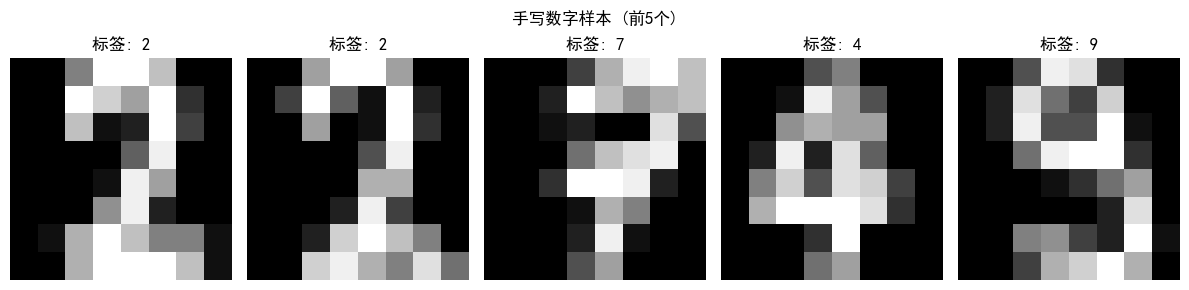


2. 初始化模型...
  输入维度: 64
  类别数量: 10
  权重矩阵形状: (64, 10)
  偏置向量形状: (1, 10)

3. 训练模型...
  超参数:
    学习率: 0.1
    正则化系数: 0.01
    批量大小: 32
    训练轮数: 50
Epoch 5/50: Train Loss: 1.0801, Val Loss: 1.0043, Train Acc: 0.8895, Val Acc: 0.9167
Epoch 10/50: Train Loss: 0.8587, Val Loss: 0.8250, Train Acc: 0.9199, Val Acc: 0.9410
Epoch 15/50: Train Loss: 0.8011, Val Loss: 0.7780, Train Acc: 0.9278, Val Acc: 0.9549
Epoch 20/50: Train Loss: 0.7774, Val Loss: 0.7603, Train Acc: 0.9382, Val Acc: 0.9514
Epoch 25/50: Train Loss: 0.7656, Val Loss: 0.7508, Train Acc: 0.9452, Val Acc: 0.9618
Epoch 30/50: Train Loss: 0.7594, Val Loss: 0.7470, Train Acc: 0.9469, Val Acc: 0.9583
Epoch 35/50: Train Loss: 0.7556, Val Loss: 0.7433, Train Acc: 0.9469, Val Acc: 0.9618
Epoch 40/50: Train Loss: 0.7527, Val Loss: 0.7415, Train Acc: 0.9443, Val Acc: 0.9618
Epoch 45/50: Train Loss: 0.7494, Val Loss: 0.7412, Train Acc: 0.9495, Val Acc: 0.9618
Epoch 50/50: Train Loss: 0.7497, Val Loss: 0.7404, Train Acc: 0.9487, Val Acc: 0.

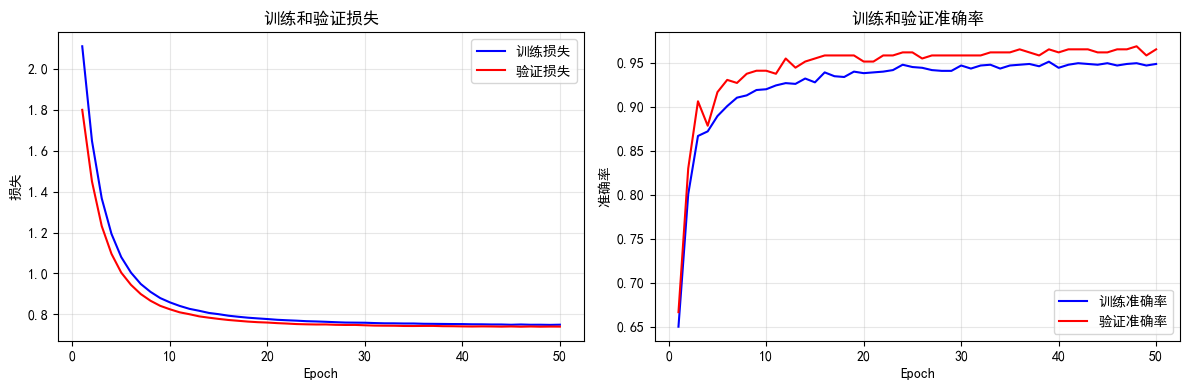


模型评估结果
测试集准确率: 0.9389
训练集准确率: 0.9487

混淆矩阵 (前5x5):
  真实类别0: [35  0  0  0  1]
  真实类别1: [ 0 30  0  0  0]
  真实类别2: [ 0  0 35  0  0]
  真实类别3: [ 0  0  0 37  0]
  真实类别4: [ 0  0  0  0 36]

分类报告:
              precision    recall  f1-score   support

           0     1.0000    0.9722    0.9859        36
           1     0.7895    0.8333    0.8108        36
           2     1.0000    1.0000    1.0000        35
           3     1.0000    1.0000    1.0000        37
           4     0.9474    1.0000    0.9730        36
           5     0.9730    0.9730    0.9730        37
           6     0.9714    0.9444    0.9577        36
           7     0.9231    1.0000    0.9600        36
           8     0.8966    0.7429    0.8125        35
           9     0.8919    0.9167    0.9041        36

    accuracy                         0.9389       360
   macro avg     0.9393    0.9382    0.9377       360
weighted avg     0.9395    0.9389    0.9381       360


5. 可视化预测结果...


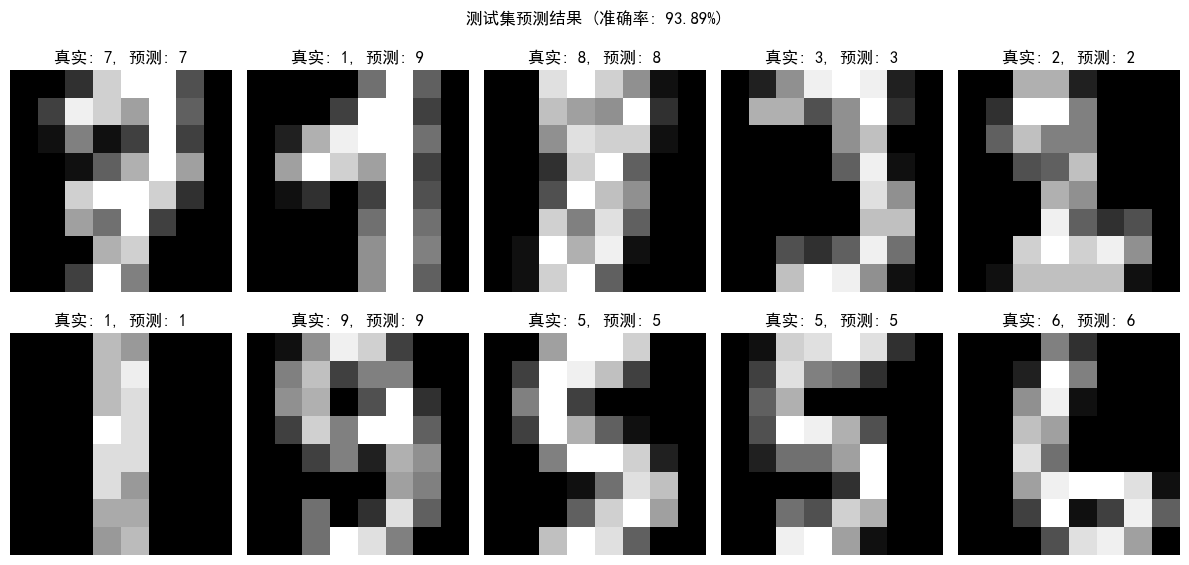


训练完成!
最终测试集准确率: 0.9389


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import warnings
warnings.filterwarnings('ignore')

# 设置随机种子以确保可重复性
np.random.seed(42)

class SoftmaxRegression:
    """
    从零实现的Softmax回归模型
    """
    
    def __init__(self, input_dim, num_classes, learning_rate=0.1, reg_lambda=0.01):
        """
        初始化模型参数
        
        参数:
        - input_dim: 输入特征维度
        - num_classes: 类别数量
        - learning_rate: 学习率
        - reg_lambda: L2正则化系数
        """
        self.input_dim = input_dim
        self.num_classes = num_classes
        self.learning_rate = learning_rate
        self.reg_lambda = reg_lambda
        
        # 初始化权重矩阵 W (input_dim x num_classes) 和偏置 b (num_classes,)
        # 使用 Xavier/Glorot 初始化
        self.W = np.random.randn(input_dim, num_classes) * np.sqrt(2.0 / input_dim)
        self.b = np.zeros((1, num_classes))
    
    def softmax(self, z):
        """
        Softmax函数
        参数:
        - z: 输入 (n_samples x num_classes)
        返回:
        - softmax激活后的概率分布
        """
        # 防止数值溢出，减去每行的最大值
        z_exp = np.exp(z - np.max(z, axis=1, keepdims=True))
        return z_exp / np.sum(z_exp, axis=1, keepdims=True)
    
    def one_hot_encode(self, y, num_classes=None):
        """
        将标签转换为one-hot编码
        参数:
        - y: 标签向量 (n_samples,)
        - num_classes: 类别数
        返回:
        - one-hot编码矩阵 (n_samples x num_classes)
        """
        if num_classes is None:
            num_classes = self.num_classes
        
        n_samples = len(y)
        y_one_hot = np.zeros((n_samples, num_classes))
        y_one_hot[np.arange(n_samples), y] = 1
        return y_one_hot
    
    def cross_entropy_loss(self, y_pred, y_true, y_one_hot=None):
        """
        计算交叉熵损失
        参数:
        - y_pred: 预测概率 (n_samples x num_classes)
        - y_true: 真实标签 (n_samples,) 或 (n_samples x num_classes)
        返回:
        - 损失值
        """
        n_samples = y_pred.shape[0]
        
        # 如果y_true是整数标签，转换为one-hot
        if y_one_hot is None:
            if y_true.ndim == 1 or y_true.shape[1] == 1:
                y_true = self.one_hot_encode(y_true.reshape(-1), self.num_classes)
        
        # 计算交叉熵损失
        # 添加小epsilon避免log(0)
        epsilon = 1e-10
        loss = -np.sum(y_true * np.log(y_pred + epsilon)) / n_samples
        
        # 添加L2正则化
        loss += 0.5 * self.reg_lambda * np.sum(self.W * self.W)
        
        return loss
    
    def forward(self, X):
        """
        前向传播
        参数:
        - X: 输入数据 (n_samples x input_dim)
        返回:
        - 预测概率 (n_samples x num_classes)
        """
        # 线性变换: z = XW + b
        z = X @ self.W + self.b
        
        # Softmax激活
        probs = self.softmax(z)
        
        return probs
    
    def compute_gradients(self, X, y_true, y_pred):
        """
        计算梯度
        参数:
        - X: 输入数据 (n_samples x input_dim)
        - y_true: 真实标签 (n_samples,) 或 (n_samples x num_classes)
        - y_pred: 预测概率 (n_samples x num_classes)
        返回:
        - dW, db: 权重和偏置的梯度
        """
        n_samples = X.shape[0]
        
        # 将y_true转换为one-hot编码
        if y_true.ndim == 1 or y_true.shape[1] == 1:
            y_true_one_hot = self.one_hot_encode(y_true.reshape(-1), self.num_classes)
        else:
            y_true_one_hot = y_true
        
        # 计算梯度: dL/dz = y_pred - y_true
        dz = y_pred - y_true_one_hot
        
        # 计算权重梯度: dL/dW = (1/n) * X^T * dz + λW
        dW = (X.T @ dz) / n_samples + self.reg_lambda * self.W
        
        # 计算偏置梯度: dL/db = (1/n) * sum(dz)
        db = np.sum(dz, axis=0, keepdims=True) / n_samples
        
        return dW, db
    
    def backward(self, X, y_true, y_pred):
        """
        反向传播更新参数
        参数:
        - X: 输入数据 (n_samples x input_dim)
        - y_true: 真实标签 (n_samples,) 或 (n_samples x num_classes)
        - y_pred: 预测概率 (n_samples x num_classes)
        """
        dW, db = self.compute_gradients(X, y_true, y_pred)
        
        # 使用梯度下降更新参数
        self.W -= self.learning_rate * dW
        self.b -= self.learning_rate * db
    
    def predict(self, X):
        """
        预测类别
        参数:
        - X: 输入数据 (n_samples x input_dim)
        返回:
        - 预测的类别标签 (n_samples,)
        """
        probs = self.forward(X)
        return np.argmax(probs, axis=1)
    
    def accuracy(self, y_pred, y_true):
        """
        计算准确率
        参数:
        - y_pred: 预测标签 (n_samples,)
        - y_true: 真实标签 (n_samples,)
        返回:
        - 准确率
        """
        return np.mean(y_pred == y_true)
    
    def train(self, X_train, y_train, X_val, y_val, batch_size=32, epochs=50, verbose=True):
        """
        训练模型
        参数:
        - X_train: 训练数据
        - y_train: 训练标签
        - X_val: 验证数据
        - y_val: 验证标签
        - batch_size: 批次大小
        - epochs: 训练轮数
        - verbose: 是否打印训练信息
        返回:
        - 训练历史记录
        """
        n_samples = X_train.shape[0]
        history = {
            'train_loss': [],
            'val_loss': [],
            'train_acc': [],
            'val_acc': []
        }
        
        for epoch in range(epochs):
            # 随机打乱数据
            indices = np.random.permutation(n_samples)
            X_train_shuffled = X_train[indices]
            y_train_shuffled = y_train[indices]
            
            epoch_loss = 0.0
            n_batches = 0
            
            # 小批量梯度下降
            for i in range(0, n_samples, batch_size):
                # 获取当前批次
                X_batch = X_train_shuffled[i:i+batch_size]
                y_batch = y_train_shuffled[i:i+batch_size]
                
                # 前向传播
                y_pred_batch = self.forward(X_batch)
                
                # 计算损失
                batch_loss = self.cross_entropy_loss(y_pred_batch, y_batch)
                epoch_loss += batch_loss
                n_batches += 1
                
                # 反向传播
                self.backward(X_batch, y_batch, y_pred_batch)
            
            # 计算平均训练损失
            avg_train_loss = epoch_loss / n_batches if n_batches > 0 else 0
            
            # 在验证集上评估
            train_pred = self.predict(X_train)
            train_acc = self.accuracy(train_pred, y_train)
            
            val_pred = self.predict(X_val)
            val_acc = self.accuracy(val_pred, y_val)
            
            val_probs = self.forward(X_val)
            val_loss = self.cross_entropy_loss(val_probs, y_val)
            
            # 保存历史记录
            history['train_loss'].append(avg_train_loss)
            history['val_loss'].append(val_loss)
            history['train_acc'].append(train_acc)
            history['val_acc'].append(val_acc)
            
            # 打印训练信息
            if verbose and (epoch + 1) % 5 == 0:
                print(f"Epoch {epoch+1}/{epochs}: "
                      f"Train Loss: {avg_train_loss:.4f}, "
                      f"Val Loss: {val_loss:.4f}, "
                      f"Train Acc: {train_acc:.4f}, "
                      f"Val Acc: {val_acc:.4f}")
        
        return history

def load_and_preprocess_data():
    """
    加载和预处理数据
    """
    # 加载手写数字数据集
    digits = load_digits()
    X = digits.data
    y = digits.target
    
    print(f"数据集信息:")
    print(f"  样本数量: {X.shape[0]}")
    print(f"  特征数量: {X.shape[1]}")
    print(f"  类别数量: {len(np.unique(y))}")
    print(f"  类别分布: {np.bincount(y)}")
    
    # 划分训练集和测试集
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # 划分训练集和验证集
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
    )
    
    # 归一化：将像素值从[0, 16]缩放到[0, 1]
    X_train = X_train / 16.0
    X_val = X_val / 16.0
    X_test = X_test / 16.0
    
    print(f"\n数据划分:")
    print(f"  训练集: {X_train.shape[0]} 个样本")
    print(f"  验证集: {X_val.shape[0]} 个样本")
    print(f"  测试集: {X_test.shape[0]} 个样本")
    
    return X_train, X_val, X_test, y_train, y_val, y_test

def visualize_data(X, y, num_samples=5):
    """
    可视化数据样本
    """
    fig, axes = plt.subplots(1, num_samples, figsize=(12, 3))
    
    for i in range(num_samples):
        ax = axes[i]
        # 将图像重塑为8x8
        img = X[i].reshape(8, 8)
        ax.imshow(img, cmap='gray')
        ax.set_title(f"标签: {y[i]}")
        ax.axis('off')
    
    plt.suptitle(f"手写数字样本 (前{num_samples}个)")
    plt.tight_layout()
    plt.show()

def plot_training_history(history):
    """
    绘制训练历史
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # 绘制损失曲线
    epochs = range(1, len(history['train_loss']) + 1)
    axes[0].plot(epochs, history['train_loss'], 'b-', label='训练损失')
    axes[0].plot(epochs, history['val_loss'], 'r-', label='验证损失')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('损失')
    axes[0].set_title('训练和验证损失')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 绘制准确率曲线
    axes[1].plot(epochs, history['train_acc'], 'b-', label='训练准确率')
    axes[1].plot(epochs, history['val_acc'], 'r-', label='验证准确率')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('准确率')
    axes[1].set_title('训练和验证准确率')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def evaluate_model(model, X_test, y_test, X_train=None, y_train=None):
    """
    评估模型性能
    """
    print("\n" + "="*50)
    print("模型评估结果")
    print("="*50)
    
    # 在测试集上评估
    y_test_pred = model.predict(X_test)
    test_acc = model.accuracy(y_test_pred, y_test)
    
    print(f"测试集准确率: {test_acc:.4f}")
    
    # 在训练集上评估（如果提供）
    if X_train is not None and y_train is not None:
        y_train_pred = model.predict(X_train)
        train_acc = model.accuracy(y_train_pred, y_train)
        print(f"训练集准确率: {train_acc:.4f}")
    
    # 计算混淆矩阵
    from sklearn.metrics import confusion_matrix, classification_report
    
    cm = confusion_matrix(y_test, y_test_pred)
    
    print(f"\n混淆矩阵 (前5x5):")
    for i in range(min(5, cm.shape[0])):
        print(f"  真实类别{i}: {cm[i, :5]}")
    
    # 打印分类报告
    print(f"\n分类报告:")
    report = classification_report(y_test, y_test_pred, digits=4)
    print(report)
    
    return test_acc, cm

def main():
    """
    主函数
    """
    print("="*60)
    print("从零实现 Softmax 回归 - MNIST 手写数字分类")
    print("="*60)
    
    # 1. 加载和预处理数据
    print("\n1. 加载和预处理数据...")
    X_train, X_val, X_test, y_train, y_val, y_test = load_and_preprocess_data()
    
    # 可视化数据样本
    visualize_data(X_train * 16.0, y_train, num_samples=5)
    
    # 2. 初始化模型
    print("\n2. 初始化模型...")
    input_dim = X_train.shape[1]  # 64 (8x8图像展平)
    num_classes = 10  # 数字0-9
    
    model = SoftmaxRegression(
        input_dim=input_dim,
        num_classes=num_classes,
        learning_rate=0.1,  # 使用给定的学习率0.1
        reg_lambda=0.01
    )
    
    print(f"  输入维度: {input_dim}")
    print(f"  类别数量: {num_classes}")
    print(f"  权重矩阵形状: {model.W.shape}")
    print(f"  偏置向量形状: {model.b.shape}")
    
    # 3. 训练模型
    print("\n3. 训练模型...")
    print(f"  超参数:")
    print(f"    学习率: {model.learning_rate}")
    print(f"    正则化系数: {model.reg_lambda}")
    print(f"    批量大小: 32")
    print(f"    训练轮数: 50")
    
    history = model.train(
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        batch_size=32,  # 使用给定的批量大小32
        epochs=50,      # 使用给定的训练轮数50
        verbose=True
    )
    
    # 4. 绘制训练历史
    print("\n4. 绘制训练曲线...")
    plot_training_history(history)
    
    # 5. 评估模型
    test_acc, cm = evaluate_model(
        model=model,
        X_test=X_test,
        y_test=y_test,
        X_train=X_train,
        y_train=y_train
    )
    
    # 6. 可视化一些预测结果
    print("\n5. 可视化预测结果...")
    n_samples_to_show = 10
    indices = np.random.choice(len(X_test), n_samples_to_show, replace=False)
    
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    axes = axes.ravel()
    
    for i, idx in enumerate(indices):
        ax = axes[i]
        img = X_test[idx].reshape(8, 8)
        true_label = y_test[idx]
        pred_label = model.predict(X_test[idx:idx+1])[0]
        
        ax.imshow(img, cmap='gray')
        ax.set_title(f"真实: {true_label}, 预测: {pred_label}")
        ax.axis('off')
        
        # 高亮显示错误预测
        if true_label != pred_label:
            for spine in ax.spines.values():
                spine.set_edgecolor('red')
                spine.set_linewidth(3)
    
    plt.suptitle(f"测试集预测结果 (准确率: {test_acc:.2%})")
    plt.tight_layout()
    plt.show()
    
    # 7. 输出最终结果
    print("\n" + "="*60)
    print("训练完成!")
    print(f"最终测试集准确率: {test_acc:.4f}")
    print("="*60)
    
    return model, history, test_acc

if __name__ == "__main__":
    model, history, test_acc = main()

步骤1: 生成数据
----------------------------------------
生成数据: 总样本数=400, 每类样本数=200
特征维度: 2
类别分布: 类别0有200个样本, 类别1有200个样本


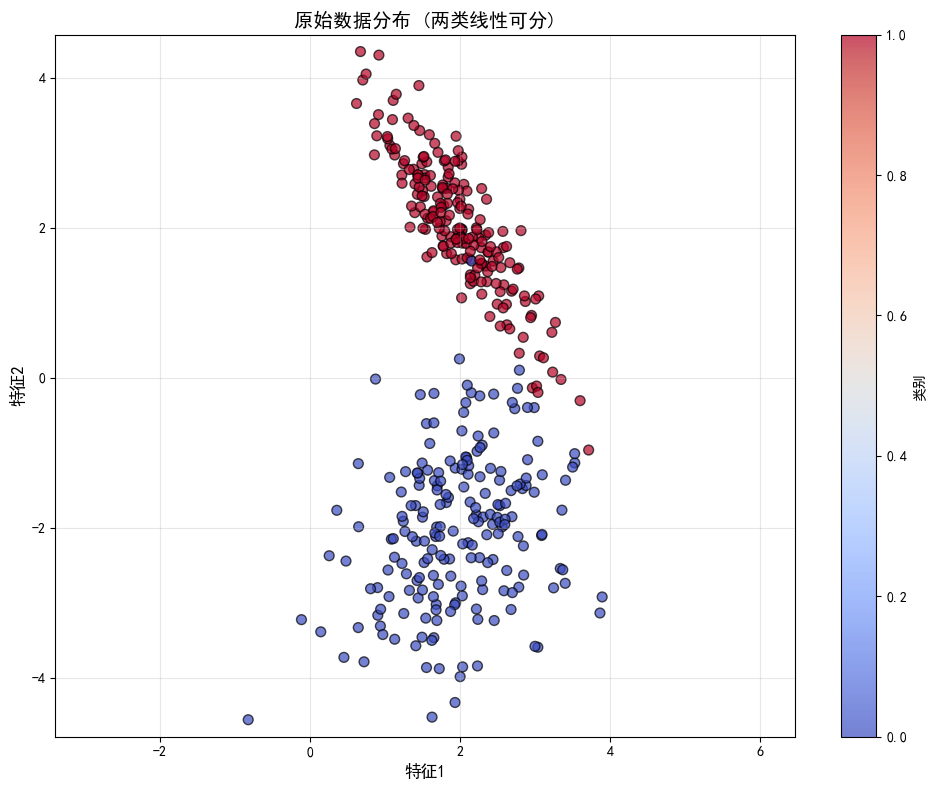


步骤2: 划分训练集和测试集
----------------------------------------

数据划分:
训练集大小: 320
测试集大小: 80

步骤3: 训练逻辑回归模型
----------------------------------------
开始训练逻辑回归模型
训练集大小: 320
特征维度: 2
迭代次数: 1000
学习率: 0.1
Iteration  100/1000 | Loss: 0.096998 | Train Acc: 0.9781 | Val Acc: 0.9875
Iteration  200/1000 | Loss: 0.080492 | Train Acc: 0.9781 | Val Acc: 0.9875
Iteration  300/1000 | Loss: 0.074471 | Train Acc: 0.9781 | Val Acc: 0.9875
Iteration  400/1000 | Loss: 0.071280 | Train Acc: 0.9781 | Val Acc: 0.9875
Iteration  500/1000 | Loss: 0.069261 | Train Acc: 0.9781 | Val Acc: 0.9875
Iteration  600/1000 | Loss: 0.067839 | Train Acc: 0.9781 | Val Acc: 0.9875
Iteration  700/1000 | Loss: 0.066760 | Train Acc: 0.9781 | Val Acc: 0.9875
Iteration  800/1000 | Loss: 0.065897 | Train Acc: 0.9781 | Val Acc: 0.9875
Iteration  900/1000 | Loss: 0.065177 | Train Acc: 0.9781 | Val Acc: 0.9875
Iteration 1000/1000 | Loss: 0.064558 | Train Acc: 0.9781 | Val Acc: 0.9875
训练完成!

步骤4: 绘制训练历史
----------------------------------------

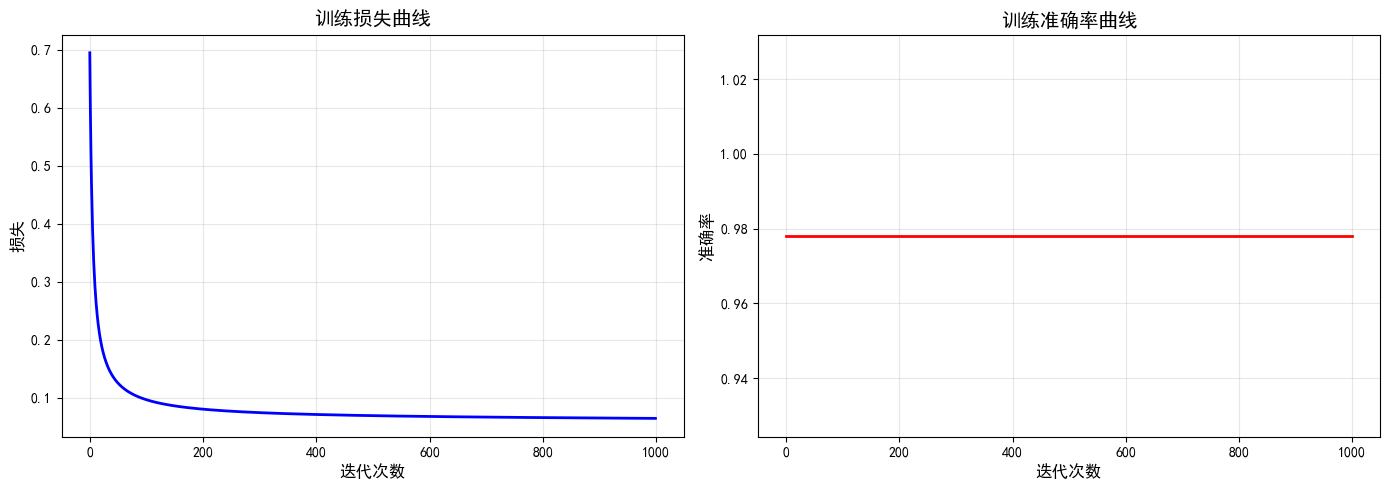


步骤5: 绘制决策边界
----------------------------------------


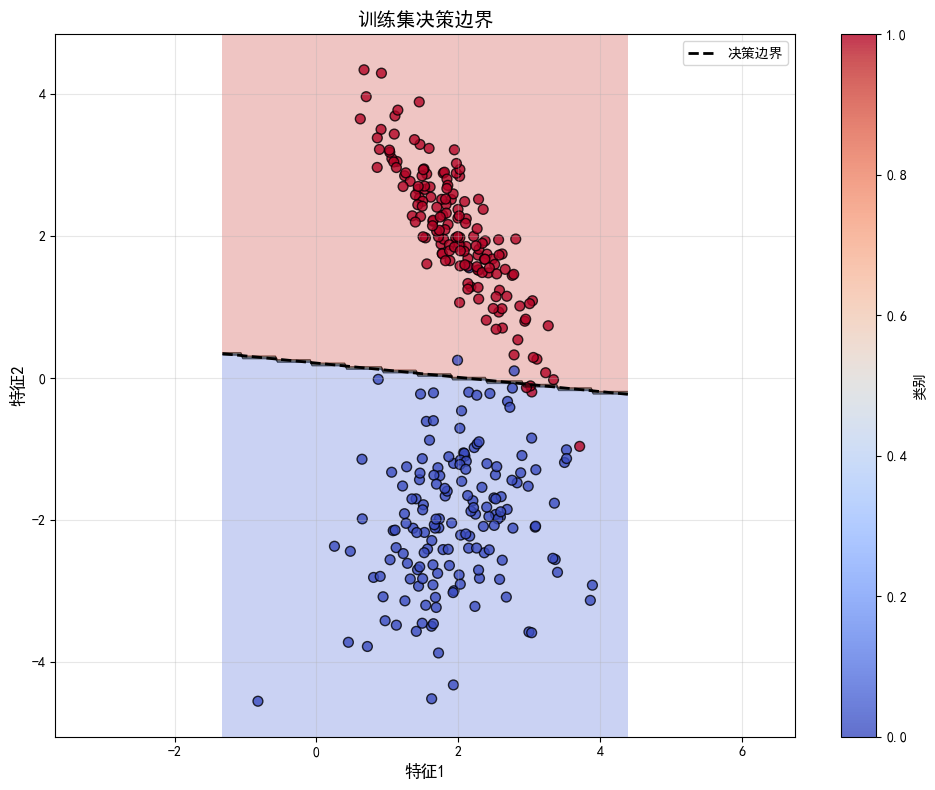

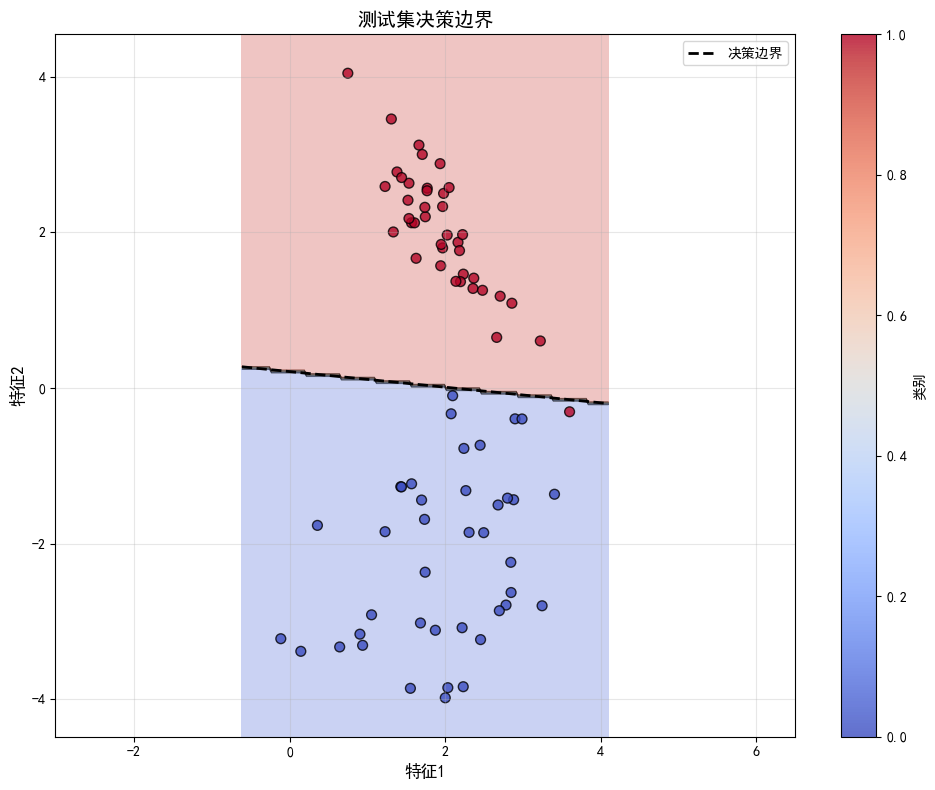


步骤6: 评估模型性能
----------------------------------------
模型评估结果
测试集准确率: 0.9875 (98.75%)

分类报告:
              precision    recall  f1-score   support

        类别 0       0.98      1.00      0.99        40
        类别 1       1.00      0.97      0.99        40

    accuracy                           0.99        80
   macro avg       0.99      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80

训练集准确率: 0.9781 (97.81%)
训练集-测试集准确率差: 0.0094

步骤7: 绘制混淆矩阵
----------------------------------------


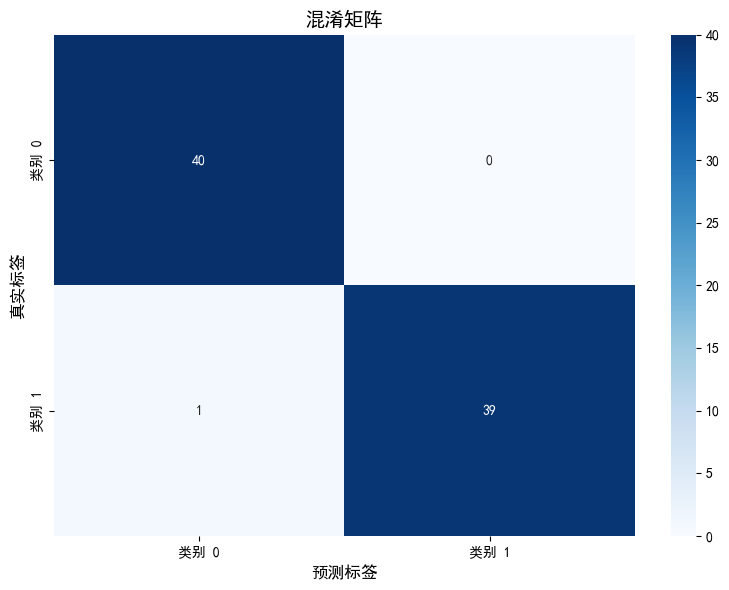


步骤8: 可视化概率曲面
----------------------------------------


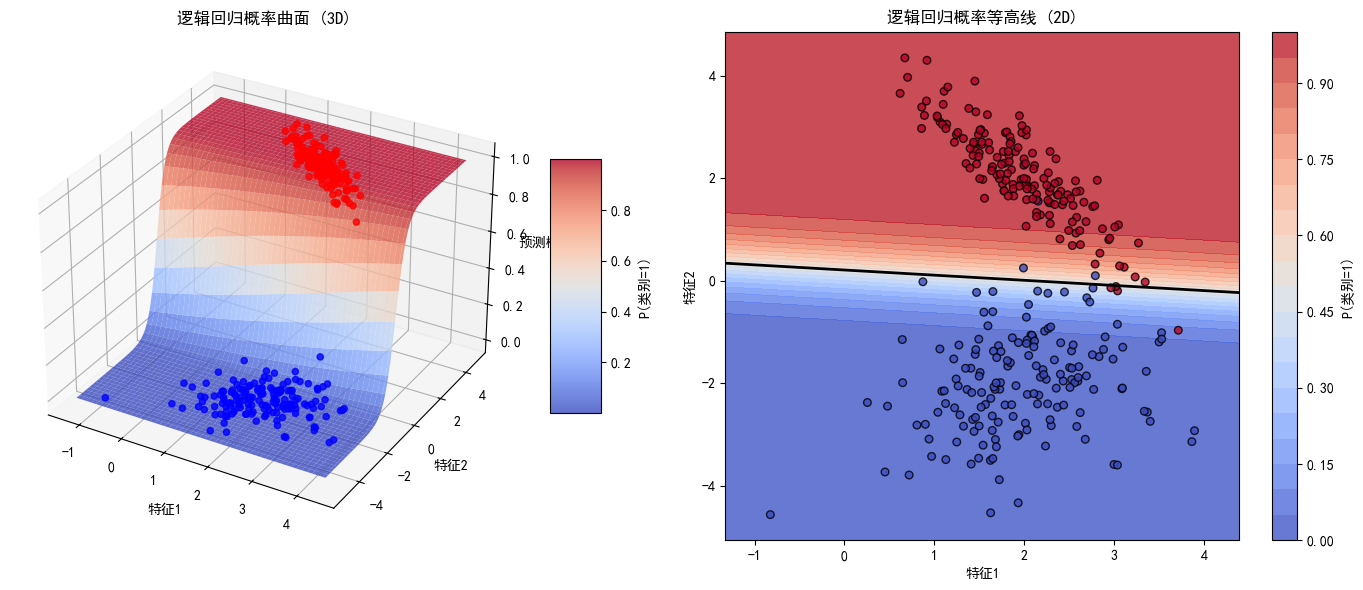


步骤9: 在新生成的测试集上评估
----------------------------------------
生成数据: 总样本数=100, 每类样本数=50
特征维度: 2
类别分布: 类别0有50个样本, 类别1有50个样本
新测试集大小: 100
新测试集准确率: 0.9500 (95.00%)

新测试集分类报告:
              precision    recall  f1-score   support

        类别 0       0.91      1.00      0.95        50
        类别 1       1.00      0.90      0.95        50

    accuracy                           0.95       100
   macro avg       0.95      0.95      0.95       100
weighted avg       0.95      0.95      0.95       100



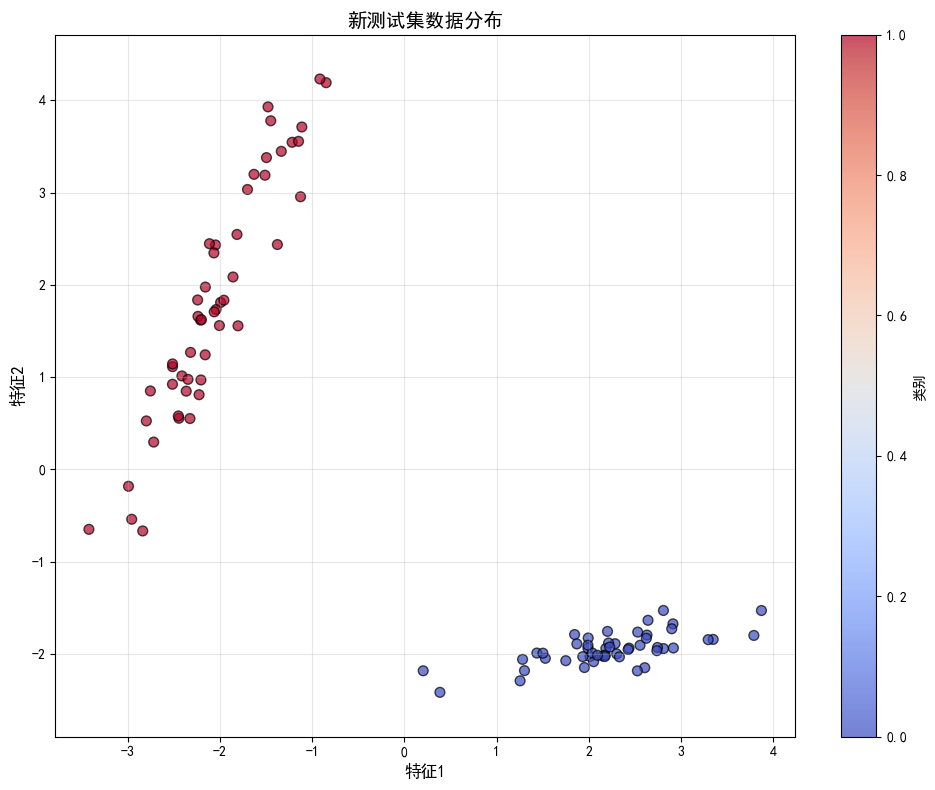

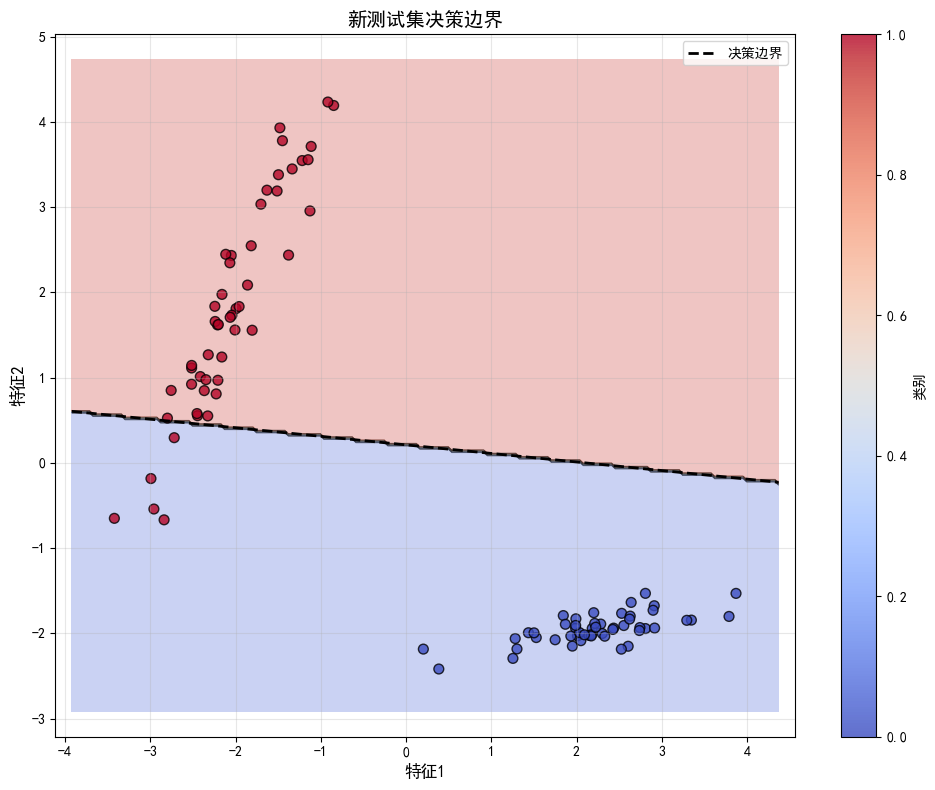


步骤10: 模型参数
----------------------------------------
权重 (w): [0.301017, 2.998396]
偏置 (b): -0.632899

决策边界方程: 0.301017 * x1 + 2.998396 * x2 + -0.632899 = 0
或: x2 = -0.100393 * x1 + 0.211079

模型使用示例

示例1: 对新样本进行预测
样本 1: 特征=[1.5 2. ], 预测概率=0.9970, 预测类别=1
样本 2: 特征=[-1. -2.], 预测概率=0.0010, 预测类别=0
样本 3: 特征=[0.  0.5], 预测概率=0.7040, 预测类别=1

示例2: 使用不同的阈值
使用阈值 0.3: 预测类别 = [1 0 1]
使用阈值 0.7: 预测类别 = [1 0 1]


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

class LogisticRegression:
    """手动实现的二分类逻辑回归模型"""
    
    def __init__(self, learning_rate=0.1, n_iterations=1000, random_state=42):
        """
        初始化逻辑回归模型
        
        参数:
        learning_rate: 学习率
        n_iterations: 迭代次数
        random_state: 随机种子
        """
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.random_state = random_state
        self.weights = None
        self.bias = None
        self.loss_history = []
        self.accuracy_history = []
        
    def sigmoid(self, z):
        """
        Sigmoid激活函数
        
        参数:
        z: 线性组合结果
        
        返回:
        sigmoid(z)
        """
        # 添加数值稳定性处理
        z = np.clip(z, -500, 500)  # 防止溢出
        return 1 / (1 + np.exp(-z))
    
    def binary_cross_entropy(self, y, y_pred):
        """
        二元交叉熵损失函数
        
        参数:
        y: 真实标签 (0或1)
        y_pred: 预测概率 (0到1之间)
        
        返回:
        交叉熵损失
        """
        # 添加一个小常数防止log(0)
        epsilon = 1e-12
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        
        # 计算损失
        loss = -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
        return loss
    
    def initialize_parameters(self, n_features):
        """
        初始化模型参数
        
        参数:
        n_features: 特征数量
        """
        np.random.seed(self.random_state)
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0.0
    
    def forward(self, X):
        """
        前向传播
        
        参数:
        X: 输入特征矩阵 (n_samples, n_features)
        
        返回:
        预测概率
        """
        # 线性组合
        linear_output = np.dot(X, self.weights) + self.bias
        # Sigmoid激活
        y_pred = self.sigmoid(linear_output)
        return y_pred
    
    def backward(self, X, y, y_pred):
        """
        反向传播，计算梯度
        
        参数:
        X: 输入特征矩阵
        y: 真实标签
        y_pred: 预测概率
        
        返回:
        dw: 权重梯度
        db: 偏置梯度
        """
        n_samples = X.shape[0]
        
        # 计算误差
        error = y_pred - y
        
        # 计算梯度
        dw = (1 / n_samples) * np.dot(X.T, error)
        db = (1 / n_samples) * np.sum(error)
        
        return dw, db
    
    def update_parameters(self, dw, db):
        """
        更新模型参数
        
        参数:
        dw: 权重梯度
        db: 偏置梯度
        """
        self.weights -= self.learning_rate * dw
        self.bias -= self.learning_rate * db
    
    def predict_proba(self, X):
        """
        预测概率
        
        参数:
        X: 输入特征矩阵
        
        返回:
        预测概率
        """
        return self.forward(X)
    
    def predict(self, X, threshold=0.5):
        """
        预测类别
        
        参数:
        X: 输入特征矩阵
        threshold: 阈值，大于阈值预测为1，否则为0
        
        返回:
        预测类别
        """
        probabilities = self.forward(X)
        predictions = (probabilities >= threshold).astype(int)
        return predictions
    
    def compute_accuracy(self, y_true, y_pred):
        """
        计算准确率
        
        参数:
        y_true: 真实标签
        y_pred: 预测标签
        
        返回:
        准确率
        """
        accuracy = np.mean(y_true == y_pred)
        return accuracy
    
    def fit(self, X, y, verbose=True, validation_data=None):
        """
        训练模型
        
        参数:
        X: 训练特征
        y: 训练标签
        verbose: 是否打印训练信息
        validation_data: 验证数据 (X_val, y_val)
        
        返回:
        训练历史
        """
        n_samples, n_features = X.shape
        
        # 初始化参数
        self.initialize_parameters(n_features)
        
        if verbose:
            print("=" * 60)
            print(f"开始训练逻辑回归模型")
            print(f"训练集大小: {n_samples}")
            print(f"特征维度: {n_features}")
            print(f"迭代次数: {self.n_iterations}")
            print(f"学习率: {self.learning_rate}")
            print("=" * 60)
        
        # 训练循环
        for iteration in range(self.n_iterations):
            # 前向传播
            y_pred = self.forward(X)
            
            # 计算损失
            loss = self.binary_cross_entropy(y, y_pred)
            self.loss_history.append(loss)
            
            # 反向传播
            dw, db = self.backward(X, y, y_pred)
            
            # 更新参数
            self.update_parameters(dw, db)
            
            # 计算训练准确率
            y_pred_class = self.predict(X)
            train_accuracy = self.compute_accuracy(y, y_pred_class)
            self.accuracy_history.append(train_accuracy)
            
            # 计算验证集指标（如果提供）
            if validation_data is not None:
                X_val, y_val = validation_data
                y_val_pred = self.predict(X_val)
                val_accuracy = self.compute_accuracy(y_val, y_val_pred)
            
            # 打印训练信息
            if verbose and (iteration + 1) % 100 == 0:
                if validation_data is not None:
                    print(f"Iteration {iteration+1:4d}/{self.n_iterations} | "
                          f"Loss: {loss:.6f} | "
                          f"Train Acc: {train_accuracy:.4f} | "
                          f"Val Acc: {val_accuracy:.4f}")
                else:
                    print(f"Iteration {iteration+1:4d}/{self.n_iterations} | "
                          f"Loss: {loss:.6f} | "
                          f"Train Acc: {train_accuracy:.4f}")
        
        if verbose:
            print("=" * 60)
            print("训练完成!")
            print("=" * 60)
        
        return {
            'loss_history': self.loss_history,
            'accuracy_history': self.accuracy_history
        }
    
    def get_decision_boundary(self, X, threshold=0.5):
        """
        获取决策边界
        
        参数:
        X: 特征矩阵
        threshold: 阈值
        
        返回:
        决策边界方程
        """
        # 对于二维特征，决策边界是 w1*x1 + w2*x2 + b = 0
        # 可以表示为 x2 = -(w1*x1 + b) / w2
        w1, w2 = self.weights
        b = self.bias
        
        def boundary(x1):
            return -(w1 * x1 + b) / w2
        
        return boundary
    
    def get_parameters(self):
        """
        获取模型参数
        
        返回:
        权重和偏置
        """
        return self.weights.copy(), self.bias


def generate_linear_separable_data(n_samples_per_class=200, n_features=2, random_state=42):
    """
    生成线性可分的数据
    
    参数:
    n_samples_per_class: 每类样本数
    n_features: 特征维度
    random_state: 随机种子
    
    返回:
    X: 特征矩阵
    y: 标签
    """
    # 使用sklearn生成线性可分数据
    n_samples = n_samples_per_class * 2
    
    X, y = make_classification(
        n_samples=n_samples,
        n_features=n_features,
        n_informative=2,
        n_redundant=0,
        n_clusters_per_class=1,
        flip_y=0.0,  # 确保数据线性可分
        class_sep=2.0,  # 增加类别分离度
        random_state=random_state
    )
    
    print(f"生成数据: 总样本数={n_samples}, 每类样本数={n_samples_per_class}")
    print(f"特征维度: {n_features}")
    print(f"类别分布: 类别0有{np.sum(y==0)}个样本, 类别1有{np.sum(y==1)}个样本")
    
    return X, y


def split_data(X, y, test_size=0.2, random_state=42):
    """
    划分训练集和测试集
    
    参数:
    X: 特征矩阵
    y: 标签
    test_size: 测试集比例
    random_state: 随机种子
    
    返回:
    X_train, X_test, y_train, y_test
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    
    print(f"\n数据划分:")
    print(f"训练集大小: {X_train.shape[0]}")
    print(f"测试集大小: {X_test.shape[0]}")
    
    return X_train, X_test, y_train, y_test


def plot_data(X, y, title="数据分布"):
    """
    绘制数据散点图
    
    参数:
    X: 特征矩阵
    y: 标签
    title: 图表标题
    """
    plt.figure(figsize=(10, 8))
    
    # 绘制散点图
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, 
                          edgecolors='k', s=50, alpha=0.7)
    
    plt.xlabel("特征1", fontsize=12)
    plt.ylabel("特征2", fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.colorbar(scatter, label='类别')
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()


def plot_decision_boundary(model, X, y, title="决策边界"):
    """
    绘制决策边界
    
    参数:
    model: 训练好的逻辑回归模型
    X: 特征矩阵
    y: 真实标签
    title: 图表标题
    """
    plt.figure(figsize=(10, 8))
    
    # 创建网格来绘制决策边界
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    # 预测整个网格
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # 绘制决策边界和区域
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.contour(xx, yy, Z, colors='k', linewidths=0.5, alpha=0.5)
    
    # 绘制数据点
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, 
                          edgecolors='k', s=50, alpha=0.8)
    
    # 绘制决策边界线
    boundary_func = model.get_decision_boundary(X)
    x1_range = np.linspace(x_min, x_max, 100)
    x2_boundary = boundary_func(x1_range)
    plt.plot(x1_range, x2_boundary, 'k--', linewidth=2, label='决策边界')
    
    plt.xlabel("特征1", fontsize=12)
    plt.ylabel("特征2", fontsize=12)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.colorbar(scatter, label='类别')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()


def plot_training_history(loss_history, accuracy_history):
    """
    绘制训练历史
    
    参数:
    loss_history: 损失历史
    accuracy_history: 准确率历史
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 绘制损失曲线
    axes[0].plot(loss_history, 'b-', linewidth=2)
    axes[0].set_xlabel('迭代次数', fontsize=12)
    axes[0].set_ylabel('损失', fontsize=12)
    axes[0].set_title('训练损失曲线', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # 绘制准确率曲线
    axes[1].plot(accuracy_history, 'r-', linewidth=2)
    axes[1].set_xlabel('迭代次数', fontsize=12)
    axes[1].set_ylabel('准确率', fontsize=12)
    axes[1].set_title('训练准确率曲线', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, classes=None):
    """
    绘制混淆矩阵
    
    参数:
    y_true: 真实标签
    y_pred: 预测标签
    classes: 类别标签
    """
    if classes is None:
        classes = ['类别 0', '类别 1']
    
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('预测标签', fontsize=12)
    plt.ylabel('真实标签', fontsize=12)
    plt.title('混淆矩阵', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def evaluate_model(model, X_test, y_test, X_train=None, y_train=None):
    """
    评估模型性能
    
    参数:
    model: 训练好的模型
    X_test: 测试特征
    y_test: 测试标签
    X_train: 训练特征（可选）
    y_train: 训练标签（可选）
    """
    # 在测试集上进行预测
    y_test_pred = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    
    print("=" * 60)
    print("模型评估结果")
    print("=" * 60)
    print(f"测试集准确率: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
    print()
    
    # 打印分类报告
    print("分类报告:")
    print(classification_report(y_test, y_test_pred, 
                                target_names=['类别 0', '类别 1']))
    
    # 计算训练集准确率（如果提供了训练集）
    if X_train is not None and y_train is not None:
        y_train_pred = model.predict(X_train)
        train_accuracy = accuracy_score(y_train, y_train_pred)
        print(f"训练集准确率: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
        print(f"训练集-测试集准确率差: {abs(train_accuracy - test_accuracy):.4f}")
    
    return test_accuracy


def visualize_probability_surface(model, X, y):
    """
    可视化概率曲面
    
    参数:
    model: 训练好的模型
    X: 特征矩阵
    y: 标签
    """
    # 创建网格
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    # 预测概率
    Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # 创建3D图形
    fig = plt.figure(figsize=(14, 6))
    
    # 子图1: 3D曲面
    ax1 = fig.add_subplot(121, projection='3d')
    surf = ax1.plot_surface(xx, yy, Z, cmap='coolwarm', 
                            edgecolor='none', alpha=0.8)
    
    # 添加数据点
    colors = ['blue' if label == 0 else 'red' for label in y]
    ax1.scatter(X[:, 0], X[:, 1], y, c=colors, s=20, depthshade=True, alpha=0.8)
    
    ax1.set_xlabel('特征1', fontsize=10)
    ax1.set_ylabel('特征2', fontsize=10)
    ax1.set_zlabel('预测概率', fontsize=10)
    ax1.set_title('逻辑回归概率曲面 (3D)', fontsize=12, fontweight='bold')
    fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=5, label='P(类别=1)')
    
    # 子图2: 2D等高线
    ax2 = fig.add_subplot(122)
    contour = ax2.contourf(xx, yy, Z, levels=20, cmap='coolwarm', alpha=0.8)
    ax2.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
    
    # 添加数据点
    scatter = ax2.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', 
                          edgecolors='k', s=30, alpha=0.8)
    
    ax2.set_xlabel('特征1', fontsize=10)
    ax2.set_ylabel('特征2', fontsize=10)
    ax2.set_title('逻辑回归概率等高线 (2D)', fontsize=12, fontweight='bold')
    fig.colorbar(contour, ax=ax2, label='P(类别=1)')
    
    plt.tight_layout()
    plt.show()


def main():
    """主函数"""
    # 设置随机种子
    np.random.seed(42)
    
    # 1. 生成两类线性可分的数据
    print("步骤1: 生成数据")
    print("-" * 40)
    X, y = generate_linear_separable_data(
        n_samples_per_class=200,  # 每类200个样本
        n_features=2,  # 特征维度为2
        random_state=42
    )
    
    # 可视化生成的数据
    plot_data(X, y, title="原始数据分布 (两类线性可分)")
    
    # 2. 划分训练集和测试集
    print("\n步骤2: 划分训练集和测试集")
    print("-" * 40)
    X_train, X_test, y_train, y_test = split_data(X, y, test_size=0.2, random_state=42)
    
    # 3. 创建和训练逻辑回归模型
    print("\n步骤3: 训练逻辑回归模型")
    print("-" * 40)
    
    # 初始化模型
    model = LogisticRegression(
        learning_rate=0.1,  # 学习率0.1
        n_iterations=1000,  # 迭代1000次
        random_state=42
    )
    
    # 训练模型
    history = model.fit(
        X_train, 
        y_train, 
        verbose=True,
        validation_data=(X_test, y_test)  # 使用测试集作为验证集
    )
    
    # 4. 绘制训练历史
    print("\n步骤4: 绘制训练历史")
    print("-" * 40)
    plot_training_history(history['loss_history'], history['accuracy_history'])
    
    # 5. 绘制决策边界
    print("\n步骤5: 绘制决策边界")
    print("-" * 40)
    plot_decision_boundary(model, X_train, y_train, title="训练集决策边界")
    plot_decision_boundary(model, X_test, y_test, title="测试集决策边界")
    
    # 6. 评估模型
    print("\n步骤6: 评估模型性能")
    print("-" * 40)
    test_accuracy = evaluate_model(model, X_test, y_test, X_train, y_train)
    
    # 7. 绘制混淆矩阵
    print("\n步骤7: 绘制混淆矩阵")
    print("-" * 40)
    y_test_pred = model.predict(X_test)
    plot_confusion_matrix(y_test, y_test_pred)
    
    # 8. 可视化概率曲面
    print("\n步骤8: 可视化概率曲面")
    print("-" * 40)
    visualize_probability_surface(model, X_train, y_train)
    
    # 9. 生成新的测试集并评估
    print("\n步骤9: 在新生成的测试集上评估")
    print("-" * 40)
    
    # 生成新的测试集（100个样本）
    X_new, y_new = generate_linear_separable_data(
        n_samples_per_class=50,  # 每类50个样本，总共100个
        n_features=2,
        random_state=100  # 不同的随机种子
    )
    
    # 在新测试集上评估
    y_new_pred = model.predict(X_new)
    new_accuracy = accuracy_score(y_new, y_new_pred)
    
    print(f"新测试集大小: {X_new.shape[0]}")
    print(f"新测试集准确率: {new_accuracy:.4f} ({new_accuracy*100:.2f}%)")
    print()
    print("新测试集分类报告:")
    print(classification_report(y_new, y_new_pred, 
                                target_names=['类别 0', '类别 1']))
    
    # 可视化新测试集
    plot_data(X_new, y_new, title="新测试集数据分布")
    plot_decision_boundary(model, X_new, y_new, title="新测试集决策边界")
    
    # 10. 打印模型参数
    print("\n步骤10: 模型参数")
    print("-" * 40)
    weights, bias = model.get_parameters()
    print(f"权重 (w): [{weights[0]:.6f}, {weights[1]:.6f}]")
    print(f"偏置 (b): {bias:.6f}")
    print(f"\n决策边界方程: {weights[0]:.6f} * x1 + {weights[1]:.6f} * x2 + {bias:.6f} = 0")
    print(f"或: x2 = {-weights[0]/weights[1]:.6f} * x1 + {-bias/weights[1]:.6f}")
    
    return model, X_train, y_train, X_test, y_test, test_accuracy


if __name__ == "__main__":
    # 运行主程序
    model, X_train, y_train, X_test, y_test, test_accuracy = main()
    
    # 可选：使用模型进行预测
    print("\n" + "=" * 60)
    print("模型使用示例")
    print("=" * 60)
    
    # 示例1: 对新样本进行预测
    print("\n示例1: 对新样本进行预测")
    new_samples = np.array([[1.5, 2.0], [-1.0, -2.0], [0.0, 0.5]])
    probabilities = model.predict_proba(new_samples)
    predictions = model.predict(new_samples)
    
    for i, (sample, prob, pred) in enumerate(zip(new_samples, probabilities, predictions)):
        print(f"样本 {i+1}: 特征={sample}, 预测概率={prob:.4f}, 预测类别={pred}")
    
    # 示例2: 使用不同的阈值
    print("\n示例2: 使用不同的阈值")
    threshold = 0.3
    predictions_low_threshold = model.predict(new_samples, threshold=threshold)
    print(f"使用阈值 {threshold}: 预测类别 = {predictions_low_threshold}")
    
    threshold = 0.7
    predictions_high_threshold = model.predict(new_samples, threshold=threshold)
    print(f"使用阈值 {threshold}: 预测类别 = {predictions_high_threshold}")